# **Tutorial 2** $\cdot$ Structure Attribution Methods

> **Abstract.** To be written at the end.


**💾 Dataset.** Mutagenicity to be done.

**📦 Packages.** Packages used in this notebook inlcude:
- [RDKit](https://www.rdkit.org/docs/index.html) Cheminformatics framework for processing of SMILES strings and the calculation of molecular descriptors and fingerprints.
- [Pandas](https://pandas.pydata.org/docs/index.html) for data representation and processing.
- [Pytorch](https://docs.pytorch.org/docs/stable/index.html) and [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) for the training of simple neural network models based on the molecular representations.
- [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) framework for the construction, training and explanation of graph neural network (GNN)-based property prediction models.
- [NetworkX](https://networkx.org/) for the representation and visualization of graph structured data.
- [myerson](https://github.com/kochgroup/myerson) for computing Myerson value explanations based on cooperative game theory.
- [graph_attention_student](https://github.com/aimat-lab/graph_attention_student) for MEGAN, a self-explaining graph attention network with built-in multi-channel explanations.

In [1]:
import os
import random

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import pytorch_lightning as pl
import torch.nn as nn
import torch.nn.functional as F
import rdkit.Chem as Chem
from rdkit import RDLogger
from rich.pretty import pprint
from torch.utils.data import TensorDataset
from torch.utils.data import Subset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torchmetrics import Accuracy, F1Score

from xai_chem_review import load_dataset_mutagenicity

# Disable all RDKit warnings
RDLogger.DisableLog('rdApp.*')

/media/ssd/Programming/xai_chem_review/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_frame: pd.DataFrame = load_dataset_mutagenicity()
print(f'Loaded dataset with {data_frame.shape[0]} rows')
data_frame.head()

Loaded dataset with 6512 rows


,CAS_NO,Activity,smiles
0,2475-33-4,0,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...
1,820-75-7,1,N#C/N=C/C(=O)NCC(=O)NN
2,2435-76-9,1,N#C/N=C1/C=NC(=O)NC1=O
3,817-99-2,1,N#C/N=C/C(=O)NCC(N)=O
4,116539-70-9,1,CCCCN(CC(O)C1=C/C(=N\C#N)C(=O)C=C1)N=O


## **2.1** $\cdot$ 💡 Structure-Attributional Explanations

Unlike the previously showcased methods, structure-attribution methods operate on the level of *graph structure*. Rather than attributing importance to abstract features (e.g. molecular weight), importance scores are computed for the individual elements of the molecular graph &mdash; namely its nodes (atoms) and edges (bonds). By highlighting important nodes and edges, these methods represent a view on the  structure-activity relationships (SAR) underlying the model's predictive decisions.

One primary difference between the two types of attributional explanations is the choice of the underlying model. Feature-attibutional explanations can be more easily obtained from models which directly use these features as the basis of their predictions. As shown in the previous tutorial, simple predictive models based on molecular descriptors can be used to generate such explanations. On the contrary, structure-attributional explanations can be more easily obtained through the use of *graph neural networks (GNNs)*. Instead of a fixed-size vector input, these GNN models operate directly on the abstract graph representation of the molecule. Due to their different operating principles, most explainability methods wont be directly applicable to graph neural networks. Although many methods (including SHAP and LIME) have been adpated to work with graph neural networks as well, there also exist a plethora of approaches designed to generate explanations specifically for GNNs.

## **2.2** $\cdot$ 📚 *Graph Neural Network Explainer* (`GNNExplainer`)

The first example method from the literature was proposed by [Ying *et al.*](https://arxiv.org/abs/1903.03894) in 2019 and is called *GNNExplainer*. The method is based on the idea of using input perturbations to extract those parts of the grhttps://pytorch-geometric.readthedocs.io/en/latest/aph structure which are the most important for a given model prediction. For a given graph structure and it's original prediction, each explanation is created by optimizing the weights of a mask over the given graph. The components of the mask correspond to the individual elements of the graph (nodes and edges) and their 0 to 1 values determine if the model is able to "see" the element (=1) or not (=0) during it's prediction. In the process of multiple predictions, the components of the mask are then adjusted such that a large part of the graph is "hidden" from the model while changing the model's *prediction* as little as possible. Therefore, the final optimized mask shows the subset of nodes and edges most important to the model to form it's decision.

**Implementation.** To use GNNExplainer, we'll first have to train a graph neural network, which will be done with the popular [Pytorch Geometric (PyG)](https://pytorch-geometric.readthedocs.io/en/latest/) framework. Aside from various GNN architectures themselves, PyG has since also implemented the ``torch_geometric.explain`` package which offers existing implementations of some commong graph explanation methods - including GNNExplainer.

### Molecular Graph Processing

As previously introduced, we want to use a graph neural network based on the popular [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) library for our main property prediction model. Do do molecular property prediction, such a GNN model needs to receive the various molecules in a *graph representation*. As a very first step, before implementing the model itself, we therefore have to construct a data-processing pipeline that can be used to convert the molecules into these graph representaitons.

**Graph Representation.** On a technical level, a PyG GNN model will need to receive the graphs in the format of a `torch_geometric.data.Data` object. A first option would be to write some function `data_from_smiles` which converts a given SMILES representation of a molecule into such a `Data` object. However, as in the previous notebook, it also makes sense to invest more thought about how the graph-based explanations will be visualized later on. For the processing and handling of graphs there already exists very useful python package called `networkx`. This package also has lots of *built-in* functionality for the manipulation and visualization of these graphs which will be useful for the explanations later on. Consequently, a good option would be to use the `networkx.Graph` object as an *intermediate representation* - based on which the visualization can be handled more easily later on. Using this intermediate representation we'll therefore have to create two seperate functions `graph_from_smiles` and `data_from_graph`.

**Feature Extraction.** When converting a molecule into a machine-readable graph representation, another question that comes up is that of feature extraction. However, unlike with molecular descriptors the feature extraction in this case will have to be done on the level of individual atoms and bonds &mdash; rather than on the level of the entire molecule. When a GNN model is creating a prediction based on the graph structure of a molecule, each node and edge of this graph need to contain some form of vectorized information about whether a node represents a carbon or an oxygen atom, for example. We therefore need to implement two additional functions `encode_atom(atom: Chem.Atom) -> np.ndarray` and `encode_bond(bond:Chem.Bond) -> np.ndarray` which can be used to calculate these numeric feature vectors corresponding to the individual nodes and atoms.

In [3]:
def encode_atom(atom: Chem.Atom,
                supported_atoms: list[str] = ['C', 'N', 'O', 'S', 'P', 'Cl', 'Br', 'F'],
                ) -> np.ndarray:
    """
    Encodes a given RDKit `atom` object into a fixed-size vector representation of its properties - including 
    a one-hot encoding of the atom type, as well as information about the atom's valence and charge.
    
    :param atom: The Chem.Atom object to be converted.
    :param supported_atoms: A list of atom symbols that are supported for the one-hot encoding. 
        If the given atom's symbol is not in this list, it will be marked as unknown which is 
        an additional one-hot encoded quantity in the output vector.
        
    :return: A numpy array of shape (n_feature, ) containing the encoded atom properties.
    """
    
    # The first part of the encoded vector is a one-hot representation of the atom type. Note that only 
    # the subset of atoms defined in the `supported_atoms` list will supported for explicit encoding. 
    # If the atom's symbol is not in this list, it will be marked as unknown, which is another additional
    # one-hot encoded quantity in the output vector.
    atom_one_hot = np.zeros(len(supported_atoms), dtype = np.float32)
    if atom.GetSymbol() in supported_atoms:
        atom_one_hot[supported_atoms.index(atom.GetSymbol())] = 1.0
    
    atom_unknown = float(atom.GetSymbol() not in supported_atoms)
    
    # Additionally, we want to provide information about the atom valence and charge, as this information 
    # will also implicitly communicate the number of implicitly attached hydrogens to the atom.
    atom_valence = atom.GetTotalValence()
    atom_valence_implicit = atom.GetImplicitValence()
    atom_charge = atom.GetFormalCharge()
    
    # Finally, we package the information into a single numeric vector
    return np.array([
        *atom_one_hot,
        atom_unknown,
        atom_valence,
        atom_valence_implicit,
        atom_charge,
    ], dtype = np.float32)


def encode_bond(bond: Chem.Bond,
                supported_bond_types: list[int] = [
                    Chem.BondType.SINGLE, 
                    Chem.BondType.DOUBLE, 
                    Chem.BondType.TRIPLE, 
                ],
                ) -> np.ndarray:
    """
    Encodes a given RDKit `bond` object into a fixed-size vector representation of its properties - including
    a one-hot encoding of the bond type, as well as information about the bond's stereo configuration and whether it is aromatic.
    
    :param bond: The Chem.Bond object to be converted.
    :param supported_bond_types: A list of bond types that are supported for the one-hot encoding. 
    
    :return: A numpy array of shape (n_feature, ) containing the encoded bond properties.
    """
    # The first part of the encoded vector is a one-hot representation of the bond type.
    # Note that only the subset of bond types defined in the `supported_bond_types` list will supported for explicit encoding. 
    # If the bond type is not in this list, it will be marked as unknown, which is another additional
    # one-hot encoded quantity in the output vector.
    bond_type_one_hot = np.zeros(len(supported_bond_types), dtype = np.float32)
    if bond.GetBondType() in supported_bond_types:
        bond_type_one_hot[supported_bond_types.index(bond.GetBondType())] = 1.0
        
    bond_unknown = float(bond.GetBondType() not in supported_bond_types)
    
    # Additionally, we want to provide information about the bond's stereo configuration and whether it is aromatic.
    bond_stereo = bond.GetStereo()
    bond_aromatic = float(bond.GetIsAromatic())
    
    return np.array([
        *bond_type_one_hot,
        bond_unknown,
        bond_stereo,
        bond_aromatic,
    ], dtype = np.float32)


def graph_from_smiles(smiles: str,
                      atom_encoder: callable = encode_atom,
                      bond_encoder: callable = encode_bond,
                      ) -> nx.Graph:
    """
    Given a `smiles` string, this function constructs a graph representation corresponding to that molecule and returns 
    it in the format of a `networkx.Graph` object.
    
    :param smiles: The SMILES string of the molecule to be converted into a graph.
    :param atom_encoder: A callable function that encodes an RDKit `atom` object into a fixed size numpy array which 
        will be attached to the node representation of the molecular graph.
    :param bond_encoder: A callable function that encodes an RDKit `bond` object into a fixed size numpy array which
        will be attached to the edge representation of the molecular graph.
        
    :return: A `networkx.Graph` object representing the molecule, where nodes correspond to atoms and edges correspond to bonds.
    """
    
    ## --- Constructing MOL object ---
    # We first have to use RDKit to convert the SMILES string into a MOL object - consisting of the individual atoms and bonds 
    # that make up the molecule.
    
    mol: Chem.Mol = Chem.MolFromSmiles(smiles)

    ## --- Constructing graph from MOL object ---
    # Afterwards, we can iterate over the individual elements (atoms, bonds) of this molecule object and construct a corresponding 
    # graph representation using networkx.
    # One important aspect in this process is how to represent the individual atoms and bonds in the graph.

    g: nx.Graph = nx.Graph() # Empty graph
    
    # At first we iterate over the atoms in the molecule and add each atom as a node.
    for atom in mol.GetAtoms():
        
        # `atom_encoder` is a callable function that encodes the atom into a fixed-size vector representation.
        node_attributes: np.ndarray = atom_encoder(atom)
        
        g.add_node(
            atom.GetIdx(),
            # Associate each node with a uniquely indentifiable index.
            node_index=atom.GetIdx(),
            # Store the string (!) representation of the atom symbol as metadata. This will later on 
            # be useful for the visualization.
            node_atom=atom.GetSymbol(), 
            # Additionally attach the numeric node attributes, which will be used for the model 
            # predictions.
            node_attributes=node_attributes
        )

    # After the nodes have been added, we can iterate over the bonds in the molecule and add each bond as an edge.
    for bond in mol.GetBonds():
        
        # `bond_encoder` is a callable function that encodes the bond into a fixed-size vector representation.
        edge_attributes: np.ndarray = bond_encoder(bond)
        
        g.add_edge(
            # Edges are defined based on the indices of the nodes that are involved.
            bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(),
            # Store the string (!) representation of the bond type as metadata. This will later on
            # be useful for the visualization.
            edge_type=bond.GetBondType(),
            # Additionally attach the numeric edge attributes, which will be used for the model 
            # predictions.
            edge_attributes=edge_attributes,
        )

    # Return the now populated graph object.
    return g



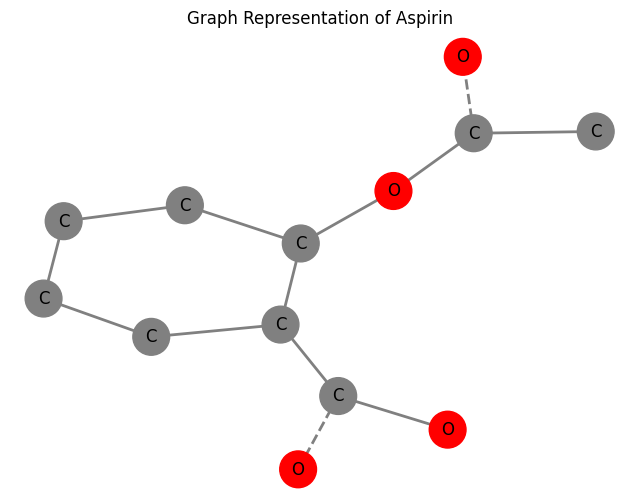

In [4]:

## --- Example molecule conversion ---

SMILES = 'CC(=O)OC1=CC=CC=C1C(=O)O'  # Acetylsalicylic acid (Aspirin)
g: nx.Graph = graph_from_smiles(SMILES)

## --- Graph Visualization ---


def draw_graph(g: nx.Graph,
               ax: plt.Axes,
               atom_color_map: dict[str, str] = {
                   'C': 'gray', 
                   'O': 'red', 
                   'N': 'blue', 
                   'S': 'yellow', 
                   'P': 'orange', 
                   'Cl': 'green', 
                   'Br': 'brown', 
                   'F': 'purple'
                },
               edge_styles: dict[int, str] = {
                   Chem.BondType.SINGLE: 'solid',
                   Chem.BondType.DOUBLE: 'dashed',
                   Chem.BondType.TRIPLE: 'dashdot',
               }
               ) -> dict:
    """
    
    """
    
    pos = nx.kamada_kawai_layout(g)

    # Draw edges with different styles based on bond type
    edge_styles = {
        Chem.BondType.SINGLE: 'solid',
        Chem.BondType.DOUBLE: 'dashed',
        Chem.BondType.TRIPLE: 'dashdot',
    }

    for (u, v, data) in g.edges(data=True):
        style = edge_styles.get(data['edge_type'], 'solid')
        nx.draw_networkx_edges(
            g, pos,
            edgelist=[(u, v)],
            style=style,
            width=2,
            edge_color='gray'
        )

    # node colors based on atom type
    atom_color_map = {'C': 'gray', 'O': 'red', 'N': 'blue'}
    node_colors = [atom_color_map.get(g.nodes[node]['node_atom'], 'lightblue') for node in g.nodes()]
    nx.draw_networkx_nodes(
        g, pos,
        node_color=node_colors,
        node_size=700,
    )
    node_labels = {node: data['node_atom'] for node, data in g.nodes(data=True)}
    nx.draw_networkx_labels(g, pos, labels=node_labels, font_size=12, font_color='black')
    
    return pos
    
# We can then create a visualization of the graph using matplotlib and networkx.
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
draw_graph(g, ax)
plt.title('Graph Representation of Aspirin')
plt.axis('off')
plt.show()


In [5]:

def data_from_graph(graph: nx.Graph) -> Data:
    
    node_attributes = np.array([
        data['node_attributes'].tolist() for _, data in graph.nodes(data=True)
    ])
    edge_indices = np.array([
        (u, v)
        for (u, v) in graph.edges()
    ])
    edge_attributes = np.array([
        data['edge_attributes'].tolist() 
        for _, _, data in graph.edges(data=True)
    ])
    
    data = Data(
        x=torch.tensor(node_attributes, dtype=torch.float32),
        # NOTE: We transpose (.T) the edge index list here to have the shape (2, num_edges) as expected by the 
        # Pytorch Geometric Data class format!
        edge_index=torch.tensor(edge_indices.T, dtype=torch.long),
        # Contrary to the edge_index tensor, the edge_attr tensor has to be the shape (num_edges, num_edge_features).
        edge_attr=torch.tensor(edge_attributes, dtype=torch.float32),
    )
    
    # If the graph has a 'graph_targets' attribute, we can attach it to the data object as well.
    if graph.graph.get('graph_labels') is not None:
        data.y = torch.tensor(graph.graph['graph_labels'], dtype=torch.float32)
    
    return data
    
    
## --- Example conversion to PyG Data ---

data: Data = data_from_graph(g)
print('Graph Data Object:')
pprint(data)

Graph Data Object:


Data(x=[13, 12], edge_index=[2, 13], edge_attr=[13, 6])

### Graph Neural Network Property Prediction

To implement the *Graph Neural Network (GNN)* model itself, we will do so using the popular [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) and further wrapping the model using [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/).

In [6]:
from torch_geometric.nn.conv import GINEConv, GATv2Conv
from torch_geometric.nn.aggr import SumAggregation


class SimpleClassifier(pl.LightningModule):
    
    def __init__(self, 
                 input_dim: int,
                 edge_dim: int,
                 hidden_units: list[int] = [64, 64, 64],
                 dense_units: list[int] = [64, 32],
                 output_dim: int = 1,
                 learning_rate: float = 1e-4,
                 ) -> None:
        
        super().__init__()
        self.input_dim = input_dim
        self.edge_dim = edge_dim
        self.hidden_units = hidden_units
        self.dense_units = dense_units
        self.output_dim = output_dim
        self.learning_rate = learning_rate
        # This is method of LightningModule which should be called at some point during the construction of 
        # the model.
        self.save_hyperparameters()
        
        ## --- Define model architecture ---
        
        # As we build the architecture we will use this variable to keep track of the "current" number of 
        # units from the previously constructed layer.
        prev_units: int = hidden_units[0]
        
        # This simple linear layer will be used simply to map the dimension of the input features `input_dim` 
        # to fit with the dimension of the first hidden layer `hidden_units[0]`.
        self.lay_embedd = nn.Linear(input_dim, prev_units)
        # This is a simple linear layer that will be used to map the dimension of the *edge* features `edge_dim`
        # to a constant size of 64, which will henceforth be used as the input dimension for the
        # graph convolutional layers.
        self.lay_embedd_edge = nn.Linear(edge_dim, 64)
        
        ## --- graph convolutional layers ---
        
        
        # This list will store all the graph convolutional / message passing layers. The actual number of layers 
        # and the sizes of the hidden units will be determined by the `hidden_units` parameter given in the 
        # constructor.
        self.conv_layers = nn.ModuleList()
        prev_units: int = hidden_units[0]
        for units in hidden_units:
            # mlp = nn.Sequential(
            #     nn.Linear(prev_units, units),
            #     nn.LayerNorm(units),
            #     nn.ReLU(),
            #     nn.Linear(units, units),
            #     nn.LayerNorm(units),
            #     nn.LeakyReLU()
            # )
            # lay_conv = GINEConv(
            #     nn=mlp,
            #     edge_dim=64
            # )
            lay_conv = GATv2Conv(
                in_channels=prev_units,
                out_channels=units,
                edge_dim=64,
                heads=3,
                concat=False,
            )
            self.conv_layers.append(lay_conv)
            
            prev_units = units
            
        ## --- global pooling layer ---
        
        self.lay_pool = SumAggregation()
            
        ## --- dense layers ---
        self.dense_layers = nn.ModuleList()
        for units in dense_units:
            lay_dense = nn.Sequential(
                nn.Linear(prev_units, units),
                nn.LayerNorm(units),
                nn.ReLU()
            )
            self.dense_layers.append(lay_dense)
            prev_units = units
            
        self.lay_out = nn.Linear(prev_units, output_dim)
        
        self.criterion = nn.BCEWithLogitsLoss()
        #self.metric = F1Score(task='binary', num_classes=output_dim, threshold=0.5)
        self.metric = Accuracy(task='binary', num_classes=output_dim, threshold=0.5)
        
    def forward(self, x, edge_index, edge_attr, batch) -> torch.Tensor:
        
        # Embedding the node and edge features into a suitable embedding shape.
        edge_embedding = self.lay_embedd_edge(edge_attr)
        node_embedding = self.lay_embedd(x)
        
        # graph convolution / message passing layers
        for lay_conv in self.conv_layers:
            # updating the node embedding by the next layer of graph convolution / message passing
            node_embedding = lay_conv(
                x=node_embedding, 
                edge_index=edge_index,
                edge_attr=edge_embedding,
            )
            node_embedding = F.layer_norm(node_embedding, node_embedding.size()[1:])
            node_embedding = F.leaky_relu(node_embedding)
            
        # Global sum pooling to turn the node embeddings into a single graph embedding.
        graph_embedding = self.lay_pool(node_embedding, batch)
        
        # Using the graph embedding as the basis for the final prediction network.
        output = graph_embedding
        for lay_dense in self.dense_layers:
            output = lay_dense(output)
            
        output = self.lay_out(output)
        
        return output
    
    def training_step(self, batch: Data, batch_idx: int) -> torch.Tensor:
        """
        The training step is called for each batch of data during the training process.
        It computes the model's output and the loss, and returns the loss value.
        """
        batch_size = torch.max(batch.batch) + 1  # Number of graphs in the batch
        # Running the model forward pass to get the logits of the model's predicted classification.
        output: torch.Tensor = self(
            batch.x, 
            batch.edge_index, 
            batch.edge_attr, 
            batch.batch
        )
        # Computing the loss between the models prediction and the ground truth labels, which 
        # are also attached to the batch Data object.
        loss: torch.Tensor = self.criterion(output.view_as(batch.y), batch.y)
        
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, batch_size=batch_size)
        
        return loss
    
    def validation_step(self, batch: Data, batch_idx: int) -> None:
        """
        The validation step is called for each batch of data during the validation process.
        It computes the model's output, the loss, and updates the metric.
        """
        output: torch.Tensor = self(
            batch.x, 
            batch.edge_index, 
            batch.edge_attr, 
            batch.batch
        )
        output = F.sigmoid(output)
        
        # Computing the loss between the models prediction and the ground truth labels.
        self.metric.update(output.view_as(batch.y), batch.y)
    
    def on_validation_epoch_end(self) -> None:
        """
        This method is called at the end of the validation epoch.
        It logs the metric value and resets the metric for the next epoch.
        """
        self.log('val_metric', self.metric.compute(), prog_bar=True, on_step=False, on_epoch=True)
        self.metric.reset()
    
    def configure_optimizers(self):
        """
        This method is called by Lightning to configure the optimizer for the model.
        """
        optimizer = torch.optim.Adam(
            self.parameters(), 
            lr=self.learning_rate, 
            weight_decay=1e-5
        )
        return optimizer
    
    def forward_graphs(self, 
                       graphs: list[nx.Graph], 
                       batch_size: int = 32
                       ) -> list[np.ndarray]:
        """
        This is a convenience method that implements the forward pass of the model over a list `graphs` of networkx.Graph
        objects and returns a list of numpy arrays containign the model's predictions for each graph (in the same order 
        as the input list).
        
        :param graphs: A list of networkx.Graph objects that will be used as input to the model.
        :param batch_size: The size of the batches that will be used to process the input graphs. 
        
        :return: A list of numpy arrays, where each array corresponds to the model's prediction for a single graph in the input list.
        """
        
        with torch.no_grad():
            
            data_list: list[Data] = [data_from_graph(graph) for graph in graphs]
            loader = DataLoader(data_list, batch_size=batch_size, shuffle=False)
            
            # While operating over the batched input, we will use this list to collect the results.
            results: list[np.ndarray] = []
            
            for batch in loader:
                
                # `logits` will be a torch tensor of shape (batch_size, output_dim) containing the model's predictions 
                # in the format of the classificaiton logits.
                logits = self(batch)
                
                # We need to convert this tensor into a list of numpy arrays.
                logits_np = logits.detach().cpu().numpy()
                
                # Appending each individual result to the list.
                for ls in logits_np:
                    results.append(ls)
                    
            return results

**Converting Dataset.** Before being able to start the model training, we need to convert the dataset into the suitable representation using the `graph_from_smiles` and `data_from_graph` functions.


In [7]:
# First we can use the `graph_from_smiles` function to convert the SMILES strings in the dataset into networkx graph 
# objects.
data_frame['graph'] = data_frame['smiles'].apply(graph_from_smiles)
# However, we also want to attach the target values (stored in the "Target" column of the data frame) to the graph objects 
# as this is needed for the conversion to the Data object format used by Pytorch Geometric.
for idx, row in data_frame.iterrows():
    row['graph'].graph['graph_labels'] = row['Activity']
    
data_frame.head()

,CAS_NO,Activity,smiles,graph
0,2475-33-4,0,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,820-75-7,1,N#C/N=C/C(=O)NCC(=O)NN,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)"
2,2435-76-9,1,N#C/N=C1/C=NC(=O)NC1=O,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)"
3,817-99-2,1,N#C/N=C/C(=O)NCC(N)=O,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)"
4,116539-70-9,1,CCCCN(CC(O)C1=C/C(=N\C#N)C(=O)C=C1)N=O,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


In [8]:
# --- train-test split ---
# Balanced train-test split: sample equal number of actives (Target==1) and inactives (Target==0) for the test set

# Find indices for actives and inactives
active_indices = data_frame.index[data_frame['Activity'] == 1].tolist()
inactive_indices = data_frame.index[data_frame['Activity'] == 0].tolist()

# Sample test indices for each class
test_active = random.sample(active_indices, k=50)
test_inactive = random.sample(inactive_indices, k=50)
test_indices = test_active + test_inactive

# Remaining indices for training
train_indices = list(set(range(len(data_frame))) - set(test_indices))

# --- creating Data objects ---
# Now we can create a list of `Data` objects from the `graph` column of the `data_frame` using the 
# `data_from_graph` function defined above.

data_list_train: list[Data] = [
    data_from_graph(data_frame.iloc[index]['graph'])
    for index in train_indices
]
data_list_test: list[Data] = [
    data_from_graph(data_frame.iloc[index]['graph'])
    for index in test_indices
]

# --- creating dataloaders ---

# Finally, we can create the `DataLoader` objects from both of these subset instances. 
# Since these data loaders automatically handle the shuffling and batching of the data during training, 
# they need to receive the batch size as a constructor argument. The `num_workers` argument specifies 
# how many subprocesses to use for data loading. Together with a reasonable `prefetch_factor`, this 
# ensures that the data is loaded efficiently during training - preventing performance bottlenecks.
loader_train = DataLoader(data_list_train, batch_size=64, shuffle=True, num_workers=4, prefetch_factor=3, drop_last=True)
loader_test = DataLoader(data_list_test, batch_size=32, shuffle=False)

**Model Training.** We can finally create the model training afterwards.

In [ ]:
model = SimpleClassifier(
    input_dim=data_list_train[0].x.shape[1],
    edge_dim=data_list_train[0].edge_attr.shape[1],
    hidden_units=[128, 128, 128],
    dense_units=[128, 64, 32],
    output_dim=1,
)

trainer = pl.Trainer(
    max_epochs=25,
    accelerator='auto',
    logger=True,
    enable_progress_bar=True,
)

trainer.fit(
    model=model,
    train_dataloaders=loader_train,
    val_dataloaders=loader_test,
)

model.eval()

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/media/ssd/Programming/xai_chem_review/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lay_embedd      │ Linear            │  1.7 K │ train │     0 │
│ 1 │ lay_embedd_edge │ Linear            │    448 │ train │     0 │
│ 2 │ conv_layers     │ ModuleList        │  372 K │ train │     0 │
│ 3 │ lay_pool        │ SumAggregation    │      0 │ train │     0 │
│ 4 │ dense_layers    │ ModuleList        │ 27.3 K │ train │     0 │
│ 5 │ lay_out         │ Linear            │     33 │ train │     0 │
│ 6 │ criterion       │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 7 │ metric          │ BinaryAccuracy    │      0 │ train │     0 │
└───┴─────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 401 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 401 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/media/ssd/Programming/xai_chem_review/.venv/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/media/ssd/Programming/xai_chem_review/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data
_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to improve performance.

**Model Evaluation.** Before using the model to generate explanations, we should evaluate its predictive performance on the test set. This ensures that we are explaining a model that has learned meaningful patterns from the data.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# --- Evaluate model on test set ---

model.eval()

# Collect predictions and ground truth labels
y_true = []
y_pred_proba = []

with torch.no_grad():
    for batch in loader_test:
        batch = batch.to(model.device)
        logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        
        y_pred_proba.extend(probs.flatten())
        y_true.extend(batch.y.cpu().numpy().flatten())

y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred_proba)

print('Model Evaluation on Test Set:')
print(f'  Accuracy:  {accuracy:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1 Score:  {f1:.4f}')
print(f'  ROC-AUC:   {roc_auc:.4f}')

Model Evaluation on Test Set:
  Accuracy:  0.7800
  Precision: 0.7414
  Recall:    0.8600
  F1 Score:  0.7963
  ROC-AUC:   0.8136


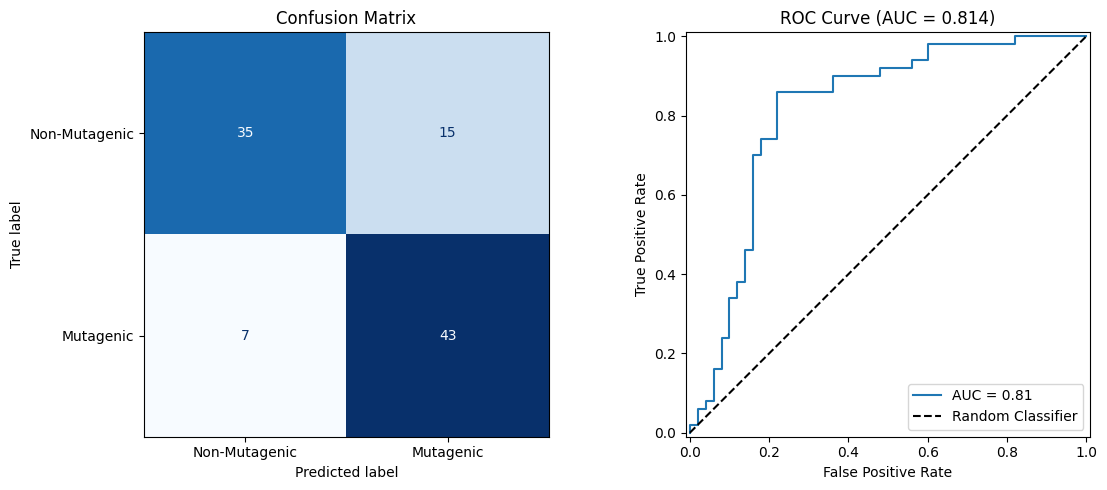

In [ ]:
# --- Visualize evaluation results ---

from sklearn.metrics import roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Mutagenic', 'Mutagenic'])
disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
disp_roc = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
disp_roc.plot(ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_title(f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

**Generating Graph Explanations.** Based on the already trained model 

In [ ]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer
from torch_geometric.explain.config import ModelConfig, ThresholdConfig

explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=300, lr=0.01),
    explanation_type='phenomenon',
    node_mask_type='object',
    edge_mask_type='object',
    model_config=ModelConfig(
        mode='binary_classification',
        task_level='graph',
        return_type='raw',
    ),
)


In [ ]:
SMILES = '[O-][N+](=O)c1cc(CCO)ccc1'

graph = graph_from_smiles(SMILES)
graph.graph['graph_labels'] = [1]
data_list = [data_from_graph(graph)]
loader = DataLoader(data_list, batch_size=len(data_list), shuffle=False)
batch = next(iter(loader))

explanation = explainer(
    x=batch.x,
    edge_index=batch.edge_index,
    edge_attr=batch.edge_attr,
    batch=batch.batch,
    target=batch.y,
    index=0
)

print('Explanation for the graph:')
pprint(explanation)

# --- updating graph with explanation ---

for node_idx, node_mask in enumerate(explanation.node_mask):
    graph.nodes[node_idx]['node_explanation'] = node_mask.detach().cpu().numpy()
    
for (u, v), edge_mask in zip(explanation.edge_index.t(), explanation.edge_mask):
    print(u, v)
    graph.edges[(u.item(), v.item())]['edge_explanation'] = edge_mask.detach().cpu().numpy()
    

Explanation for the graph:


Explanation(node_mask=[12, 1], edge_mask=[12], target=[1], index=[1], x=[12, 12], edge_index=[2, 12], edge_attr=[12, 6], batch=[12])

tensor(0) tensor(1)
tensor(1) tensor(2)
tensor(1) tensor(3)
tensor(3) tensor(4)
tensor(3) tensor(11)
tensor(4) tensor(5)
tensor(5) tensor(6)
tensor(5) tensor(9)
tensor(6) tensor(7)
tensor(7) tensor(8)
tensor(9) tensor(10)
tensor(10) tensor(11)


{
│   0: array([0.67628187, 0.5336223 ]),
│   1: array([0.3892203 , 0.45033629]),
│   2: array([0.29786241, 0.73422394]),
│   3: array([0.26460298, 0.17125005]),
│   4: array([-0.0336704 ,  0.08752997]),
│   5: array([-0.17697899, -0.1870737 ]),
│   6: array([-0.46626461, -0.23382087]),
│   7: array([-0.73687579, -0.2976085 ]),
│   8: array([-1.        , -0.37115901]),
│   9: array([ 0.02311713, -0.43004519]),
│   10: array([ 0.31987721, -0.36747194]),
│   11: array([ 0.44282789, -0.08978334])
}

/tmp/ipykernel_91705/1297013550.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scaler = np.clip(float(explanation_value), 0.0, 1.0)


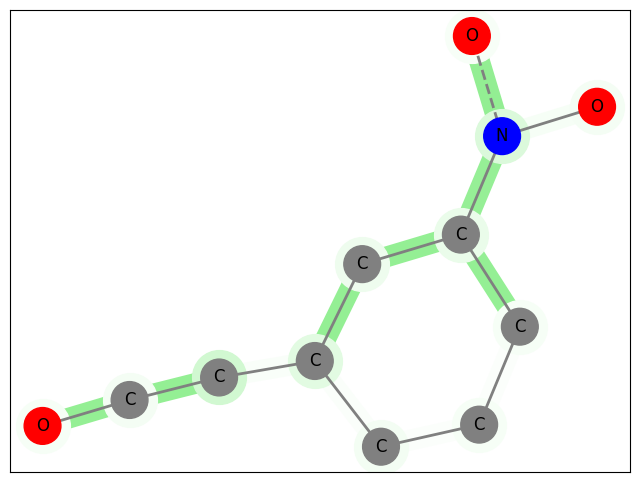

In [ ]:

import matplotlib.colors as mcolors
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

pos = draw_graph(graph, ax)
pprint(pos)

def draw_explanation(graph: nx.Graph, pos: dict, ax: plt.Axes) -> None:
    """
    Draws the explanation on the graph visualization.
    
    :param graph: The networkx graph with node explanations.
    :param ax: The matplotlib axes to draw on.
    """
    for node, data in graph.nodes(data=True):
        
        if 'node_explanation' in data:
            # Use the explanation value to determine the node color
            explanation_value = data['node_explanation']
            
            # Scale the explanation value between 0 (base lightgreen) and 1 (white)
            # We'll interpolate between lightgreen (144, 238, 144) and white (255, 255, 255)
            base_color = np.array(mcolors.to_rgb("lightgreen"))
            white = np.array([1.0, 1.0, 1.0])
            scaler = np.clip(float(explanation_value), 0.0, 1.0)
            color = scaler * base_color + (1 - scaler) * white
            
            ax.scatter(
                pos[node][0], pos[node][1],
                s=1500, color=[color],
                zorder=-10
            )
            
    for u, v, data in graph.edges(data=True):
        
        if 'edge_explanation' in data:
            # Use the explanation value to determine the edge color
            explanation_value = data['edge_explanation']
            
            # Scale the explanation value between 0 (base lightgreen) and 1 (white)
            # We'll interpolate between lightgreen (144, 238, 144) and white (255, 255, 255)
            base_color = np.array(mcolors.to_rgb("lightgreen"))
            white = np.array([1.0, 1.0, 1.0])
            scaler = np.clip(float(explanation_value), 0.0, 1.0)
            color = scaler * base_color + (1 - scaler) * white
            
            ax.plot(
                [pos[u][0], pos[v][0]], 
                [pos[u][1], pos[v][1]],
                color=color, 
                linewidth=15, 
                zorder=-20,
            )

draw_explanation(graph, pos, ax)

## **2.3** $\cdot$ 📚 *Parameterized Graph Explainer* (`PGExplainer`)

The second structure-attribution method is the *Parameterized Explainer for Graph Neural Networks* (PGExplainer), proposed by [Luo *et al.*](https://arxiv.org/abs/2011.04573) in 2020. Unlike GNNExplainer which optimizes a mask for each individual graph, PGExplainer trains a neural network (an MLP) that learns to predict edge importance across the entire dataset.

**Core Methodology.** PGExplainer works by:
1. Extracting node embeddings from intermediate layers of the GNN model
2. For each edge, concatenating the embeddings of its source and target nodes
3. Passing these concatenated embeddings through an MLP to predict edge importance
4. Training this MLP on multiple graphs so it learns general patterns of what makes edges important

**Key Difference from GNNExplainer.** While GNNExplainer optimizes a mask *per graph* (making it slow but instance-specific), PGExplainer trains *once* on the dataset and can then quickly explain new graphs. This makes PGExplainer more suitable for production use cases where explanations need to be generated rapidly.

**Implementation Notes.** The PyTorch Geometric implementation includes regularization terms (`edge_size` and `edge_ent`) that penalize large masks and encourage entropy. However, the **default values can cause problems**: they may push the MLP to output large negative logits, resulting in near-zero edge masks after sigmoid. We disable these regularization terms by setting `edge_size=0.0` and `edge_ent=0.0`.

In [ ]:
# --- Understanding PGExplainer's Internal Mechanism ---
# PGExplainer uses get_embeddings() to extract intermediate node representations
# from the GNN. Let's examine what embeddings are captured:

from torch_geometric.utils import get_embeddings

# Get a sample batch
sample_batch = next(iter(loader_train))
sample_batch = sample_batch.to(model.device)

# Extract embeddings (this is what PGExplainer does internally)
with torch.no_grad():
    _ = model(sample_batch.x, sample_batch.edge_index, sample_batch.edge_attr, sample_batch.batch)
    embeddings = get_embeddings(model, sample_batch.x, sample_batch.edge_index, 
                                 sample_batch.edge_attr, sample_batch.batch)

print(f'Number of embedding layers captured: {len(embeddings)}')
for i, emb in enumerate(embeddings):
    print(f'  Layer {i}: shape = {emb.shape}')

Number of embedding layers captured: 3
  Layer 0: shape = torch.Size([1024, 128])
  Layer 1: shape = torch.Size([1024, 128])
  Layer 2: shape = torch.Size([1024, 128])


In [ ]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import PGExplainer
from torch_geometric.explain.config import ModelConfig, ThresholdConfig

EPOCHS = 30

model.eval()
pg_explainer = Explainer(
    model=model,
    # IMPORTANT: edge_size and edge_ent are set to 0.0 to disable regularization.
    # The default values (edge_size=0.05, edge_ent=1.0) cause the MLP to output 
    # large negative logits, resulting in near-zero edge masks after sigmoid.
    # See tests/test_pgexplainer.py for diagnostic tests that reveal this issue.
    algorithm=PGExplainer(epochs=EPOCHS, lr=0.003, edge_size=0.0, edge_ent=0.0),
    explanation_type='phenomenon',
    node_mask_type=None,
    edge_mask_type='object',
    model_config=ModelConfig(
        mode='binary_classification',
        task_level='graph',
        return_type='raw',
    ),
)

# Move the explainer's MLP to the same device as the model
pg_explainer.algorithm = pg_explainer.algorithm.to(model.device)

# Create a dataloader for training the explainer
# Note: PGExplainer trains an MLP to predict edge importance, so it needs to see
# many examples during training. We use the full training set.
pg_train_loader = DataLoader(data_list_train, batch_size=1, shuffle=True)

print('Training PGExplainer...')
for epoch in range(EPOCHS):
    losses = []
    for data in pg_train_loader:
        data = data.to(model.device)
        loss = pg_explainer.algorithm.train(
            epoch=epoch,
            model=model,
            x=data.x,
            edge_index=data.edge_index,
            edge_attr=data.edge_attr,
            batch=data.batch,
            target=data.y,
        )
        losses.append(loss)
    
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f' * epoch {epoch:2d} - loss: {np.mean(losses):.4f}')

Training PGExplainer...
 * epoch  0 - loss: 0.5205


KeyboardInterrupt: 

In [ ]:
# --- Generate PGExplainer explanation for a test molecule ---

SMILES = '[O-][N+](=O)c1cc(CCO)ccc1'

graph = graph_from_smiles(SMILES)
graph.graph['graph_labels'] = [1]
data = data_from_graph(graph)
loader = DataLoader([data], batch_size=1, shuffle=False)
batch = next(iter(loader))
batch = batch.to(model.device)

explanation = pg_explainer(
    x=batch.x,
    edge_index=batch.edge_index,
    edge_attr=batch.edge_attr,
    batch=batch.batch,
    target=batch.y,
)

print('PGExplainer Explanation:')
print(f'  Edge mask shape: {explanation.edge_mask.shape}')
print(f'  Edge mask min: {explanation.edge_mask.min():.4f}')
print(f'  Edge mask max: {explanation.edge_mask.max():.4f}')
print(f'  Edge mask mean: {explanation.edge_mask.mean():.4f}')

# --- Update graph with edge explanations ---
# Note: PGExplainer only provides edge masks, not node masks

for (u, v), edge_mask in zip(explanation.edge_index.t(), explanation.edge_mask):
    u_idx, v_idx = u.item(), v.item()
    # Check if edge exists (networkx stores undirected edges once)
    if graph.has_edge(u_idx, v_idx):
        graph.edges[(u_idx, v_idx)]['edge_explanation'] = edge_mask.detach().cpu().numpy()
    elif graph.has_edge(v_idx, u_idx):
        graph.edges[(v_idx, u_idx)]['edge_explanation'] = edge_mask.detach().cpu().numpy()

In [ ]:
# --- Visualize PGExplainer explanation ---

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

pos = draw_graph(graph, ax)
draw_explanation(graph, pos, ax)

plt.title(f'PGExplainer Explanation for {SMILES}')
plt.axis('off')
plt.show()

## **2.4** $\cdot$ 📚 *Explaining GNNs with Myerson Values* (`myerson`)

The third structure-attribution method we'll explore takes a fundamentally different approach grounded in *cooperative game theory*. The method uses **Myerson values** &mdash; a generalization of the well-known Shapley values that accounts for restricted cooperation structures defined by a graph. This approach was adapted for GNN explanation and implemented in the [myerson](https://github.com/kochgroup/myerson) package.

**Core Methodology.** In cooperative game theory, Shapley values measure each player's fair contribution to a coalition by averaging their marginal contributions across all possible orderings. Myerson values extend this concept to situations where players can only cooperate if they are *connected* in a graph structure. For GNN explanation, this is a natural fit: the molecular graph defines which atoms can "cooperate" (i.e., contribute together to the prediction), and the GNN model serves as the *coalition function* that assigns a value (prediction) to each subset of connected atoms.

The key insight is that when evaluating a coalition of atoms, only *connected subgraphs* within that coalition can meaningfully contribute to the prediction. An isolated atom that is disconnected from the rest of its coalition cannot participate in message passing and thus cannot influence the GNN's output for that subgraph. The Myerson value framework naturally captures this constraint.

**Comparison to Other Methods.** Unlike GNNExplainer (which learns a mask through optimization) or PGExplainer (which trains a parameterized model), the Myerson approach provides a *theoretically grounded* attribution based on game-theoretic fairness axioms. The attributions satisfy properties like efficiency (attributions sum to the total prediction) and symmetry (identical nodes receive identical attributions). However, exact computation requires evaluating all 2^n possible coalitions, making it computationally expensive for large molecules.

**Implementation.** The `myerson` package provides both exact calculation (for smaller graphs) and Monte Carlo sampling approximation (for larger graphs). The package integrates directly with PyTorch Geometric models through the `explain()` function, which automatically selects the appropriate computation method based on graph size.

**📝 Note.** The myerson package expects models with a `forward(x, edge_index, batch)` signature. Since our `SimpleClassifier` also uses edge features via `forward(x, edge_index, edge_attr, batch)`, we need to create a thin wrapper that provides the expected interface. This is a common pattern when integrating different XAI libraries with existing models.

In [ ]:
from myerson import explain


class MyersonModelWrapper(nn.Module):
    """
    Wrapper to adapt models with edge features for use with the myerson package.
    
    The myerson package expects a model with forward(x, edge_index, batch) signature,
    but our SimpleClassifier uses forward(x, edge_index, edge_attr, batch). This wrapper
    bridges the interface gap by providing default edge attributes.
    
    :param model: The underlying GNN model to wrap.
    :param edge_dim: The dimension of edge features expected by the model.
    """
    
    def __init__(self, model: nn.Module, edge_dim: int):
        super().__init__()
        self.model = model
        self.edge_dim = edge_dim
    
    def forward(self, x, edge_index, batch):
        # Create zero edge attributes with the expected dimension
        num_edges = edge_index.shape[1]
        edge_attr = torch.zeros(num_edges, self.edge_dim, device=x.device)
        return self.model(x, edge_index, edge_attr, batch)


# --- Generate Myerson value explanations ---
# We'll use the same molecule as in the GNNExplainer example for comparison.

SMILES = '[O-][N+](=O)c1cc(CCO)ccc1'

graph = graph_from_smiles(SMILES)
graph.graph['graph_labels'] = [1]
data = data_from_graph(graph)

# Wrap the model to provide the interface expected by myerson
wrapped_model = MyersonModelWrapper(model, edge_dim=model.edge_dim)

# The explain() function automatically handles the conversion and computation.
# For graphs with <= 20 nodes, it uses exact calculation; for larger graphs,
# it falls back to Monte Carlo sampling.
print(f'Generating Myerson value explanations for: {SMILES}')
print(f'Graph has {data.x.shape[0]} nodes')

myerson_values = explain(data, wrapped_model, verbose=True)

print('\nMyerson values per node:')
for node_idx, value in myerson_values.items():
    atom_symbol = graph.nodes[node_idx]['node_atom']
    print(f'  Node {node_idx} ({atom_symbol}): {value:.4f}')

[2025-12-09 15:19:42,743 - INFO] Calculating exact Myerson values.
[2025-12-09 15:19:42,745 - INFO] using device cpu
[2025-12-09 15:19:42,747 - INFO] Calculating number of coalitions.


Generating Myerson value explanations for: [O-][N+](=O)c1cc(CCO)ccc1
Graph has 12 nodes


Calculate coalitions: 100%|██████████| 12/12 [00:00<00:00, 215092.51it/s]
[2025-12-09 15:19:42,750 - INFO] Number of coalitions: 4096
[2025-12-09 15:19:42,751 - INFO] Calculating number of graph restricted coalitions.
Calculate graph restricted coalitions: 100%|██████████| 4096/4096 [00:00<00:00, 27468.28it/s]
[2025-12-09 15:19:42,903 - INFO] Removing dublicates from 12353 graph restricted coalitions.
Remove duplicates: 100%|██████████| 12353/12353 [00:00<00:00, 4291934.83it/s]
[2025-12-09 15:19:42,909 - INFO] Number of graph restricted coalitions: 252
[2025-12-09 15:19:42,910 - INFO] Calculating worth of graph restricted coalitions.
Calculating worth of graph restricted coalitions:   0%|          | 0/252 [00:00<?, ?it/s]


AssertionError: 

In [ ]:
# --- Visualize Myerson value explanations ---
# We'll attach the Myerson values to the graph nodes and use the same visualization
# approach as with GNNExplainer.

# Normalize the Myerson values to [0, 1] range for visualization
values = np.array(list(myerson_values.values()))
min_val, max_val = values.min(), values.max()
if max_val > min_val:
    normalized_values = (values - min_val) / (max_val - min_val)
else:
    normalized_values = np.ones_like(values) * 0.5

# Attach normalized values to graph nodes
for node_idx, norm_value in zip(myerson_values.keys(), normalized_values):
    graph.nodes[node_idx]['node_explanation'] = norm_value

# Visualize the explanation
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
pos = draw_graph(graph, ax)
draw_explanation(graph, pos, ax)
plt.title('Myerson Value Explanation')
plt.axis('off')
plt.show()

NameError: name 'myerson_values' is not defined

**Interpreting Myerson Value Explanations.** The visualization above shows the Myerson value attribution for each atom in the molecule. Higher values (darker green) indicate atoms that contribute more to the model's prediction. Unlike the mask-based approaches of GNNExplainer and PGExplainer, Myerson values have a precise game-theoretic interpretation: they represent each atom's *fair share* of the total prediction, accounting for the cooperative structure defined by the molecular graph.

The Myerson values satisfy several desirable properties inherited from Shapley values:
- **Efficiency**: The sum of all node attributions equals the model's prediction for the complete graph.
- **Symmetry**: Structurally equivalent atoms receive equal attributions.
- **Null player**: Atoms that never affect the prediction receive zero attribution.

**📝 Note.** The exact computation of Myerson values has exponential complexity O(2^n) in the number of atoms. For molecules with more than ~20 atoms, the `explain()` function automatically switches to Monte Carlo sampling, which provides approximate attributions with controllable accuracy. For very large molecules, consider using the `MyersonSamplingExplainer` class directly with a specified number of samples.

## **2.5** $\cdot$ 📚 *Multi-Explanation Graph Attention Network* (`MEGAN`)

The final structure-attribution method we'll explore takes a fundamentally different approach: rather than explaining predictions *post-hoc*, it produces explanations as an **intrinsic part of the forward pass**. The *Multi-Explanation Graph Attention Network* (MEGAN) was proposed by [Teufel *et al.*](https://link.springer.com/chapter/10.1007/978-3-031-44067-0_18) in 2023 and is implemented in the [graph_attention_student](https://github.com/aimat-lab/graph_attention_student) package.

**Core Methodology.** MEGAN is built on graph attention mechanisms where the attention weights serve a dual purpose: they both guide information flow during message passing *and* directly constitute the explanation. The key innovation lies in the use of **multiple explanation channels** &mdash; parallel attention heads that capture different aspects of the prediction. For regression tasks, two channels are used: one highlighting substructures that contribute *positively* to the prediction and another highlighting substructures that contribute *negatively*. For classification tasks, the number of channels matches the number of classes, with each channel highlighting features relevant to that particular class.

The architecture consists of several components:
1. **Parallel attention encoder**: Multiple layers of graph attention, where each layer contains K parallel attention heads (one per explanation channel). The attention weights from each head determine both the message passing and the node/edge importance for that channel.
2. **Importance-weighted pooling**: Rather than simple sum or mean pooling, MEGAN uses the attention weights to perform a weighted aggregation of node embeddings into a graph embedding &mdash; separately for each channel.
3. **Channel-specific projections**: Each channel's graph embedding is independently projected before being concatenated for the final prediction.

**Comparison to Other Methods.** Unlike GNNExplainer and PGExplainer which require a separate explanation step after prediction, MEGAN produces explanations *simultaneously* with the prediction. This has several advantages: (1) explanations are always consistent with the prediction since they use the same attention weights, (2) no additional computation is needed for explanation, and (3) the model can be trained with *explanation supervision* when ground-truth explanations are available, potentially improving both prediction accuracy and explanation quality.

The multi-channel nature of MEGAN explanations is particularly valuable for understanding complex structure-activity relationships. In molecular property prediction, different functional groups may contribute opposing effects (e.g., hydrophilic vs. hydrophobic groups for solubility), and MEGAN's separate channels can capture these distinct contributions.

**Implementation.** The `graph_attention_student` package provides a PyTorch Lightning-based implementation that integrates seamlessly with PyTorch Geometric data structures. The model can be trained on any graph-level regression or classification task.

**📝 Note.** Since MEGAN is a complete model architecture rather than a post-hoc explanation method, we cannot apply it to our existing `SimpleClassifier` model. Instead, we'll train a new MEGAN model on the same dataset and compare the explanations it produces.

In [ ]:
from graph_attention_student.torch.megan import Megan
from visual_graph_datasets.processing.molecules import MoleculeProcessing

# --- Setting up MEGAN-compatible data processing ---
# MEGAN uses its own data processing pipeline from the visual_graph_datasets package.
# This processing creates node and edge features optimized for the MEGAN architecture.

processing = MoleculeProcessing()

# We'll convert our SMILES strings into the format expected by MEGAN
def graph_dict_from_smiles(smiles: str) -> dict:
    """
    Converts a SMILES string into a graph dictionary compatible with MEGAN.
    
    :param smiles: The SMILES string of the molecule.
    :returns: A dictionary containing graph data (node_indices, node_attributes, 
              edge_indices, edge_attributes).
    """
    return processing.process(smiles)


# --- Creating MEGAN-compatible dataset ---
# Convert the training and test data to MEGAN's expected format

from torch_geometric.data import Data as PyGData

def megan_data_from_smiles(smiles: str, target: float) -> PyGData:
    """
    Creates a PyTorch Geometric Data object from a SMILES string for use with MEGAN.
    
    :param smiles: The SMILES string of the molecule.
    :param target: The target value (0 or 1 for classification).
    :returns: A PyG Data object compatible with MEGAN.
    """
    graph_dict = graph_dict_from_smiles(smiles)
    
    data = PyGData(
        x=torch.tensor(graph_dict['node_attributes'], dtype=torch.float32),
        edge_index=torch.tensor(graph_dict['edge_indices'], dtype=torch.long).t().contiguous(),
        edge_attr=torch.tensor(graph_dict['edge_attributes'], dtype=torch.float32),
        y=torch.tensor([target], dtype=torch.float32),
    )
    return data


# Convert datasets
print('Converting dataset for MEGAN...')
megan_data_train = [
    megan_data_from_smiles(data_frame.iloc[idx]['smiles'], data_frame.iloc[idx]['Activity'])
    for idx in train_indices
]
megan_data_test = [
    megan_data_from_smiles(data_frame.iloc[idx]['smiles'], data_frame.iloc[idx]['Activity'])
    for idx in test_indices
]

print(f'Training set: {len(megan_data_train)} samples')
print(f'Test set: {len(megan_data_test)} samples')
print(f'Node features dimension: {megan_data_train[0].x.shape[1]}')
print(f'Edge features dimension: {megan_data_train[0].edge_attr.shape[1]}')

Converting dataset for MEGAN...
Training set: 6412 samples
Test set: 100 samples
Node features dimension: 10
Edge features dimension: 4


In [ ]:
# --- Creating and training the MEGAN model ---
# MEGAN is a PyTorch Lightning module, so we can train it using the familiar Lightning Trainer.

# Create data loaders for MEGAN
megan_loader_train = DataLoader(megan_data_train, batch_size=64, shuffle=True, num_workers=4, prefetch_factor=3, drop_last=True)
megan_loader_test = DataLoader(megan_data_test, batch_size=32, shuffle=False)

# Create the MEGAN model
# For binary classification, we use 2 channels: one for the "positive" class contribution
# and one for the "negative" class contribution
megan_model = Megan(
    node_dim=megan_data_train[0].x.shape[1],
    edge_dim=megan_data_train[0].edge_attr.shape[1],
    units=[64, 64, 64],                    # Graph encoder layer sizes
    final_units=[64, 32, 1],               # Prediction MLP layer sizes
    num_channels=2,                         # Number of explanation channels
    importance_factor=0.0,                  # Set >0 for explanation supervision (if ground truth available)
    sparsity_factor=0.1,                    # Promotes sparse explanations
    prediction_mode='bce',                  # Binary cross-entropy for classification
    learning_rate=1e-3,
)

print('MEGAN model architecture:')
print(f'  Node input dim: {megan_model.node_dim}')
print(f'  Edge input dim: {megan_model.edge_dim}')
print(f'  Explanation channels: {megan_model.num_channels}')
print(f'  Prediction mode: {megan_model.prediction_mode}')

MEGAN model architecture:
  Node input dim: 10
  Edge input dim: 4
  Explanation channels: 2
  Prediction mode: bce


In [ ]:
# --- Training the MEGAN model ---

megan_trainer = pl.Trainer(
    max_epochs=25,
    accelerator='auto',
    logger=True,
    enable_progress_bar=True,
)

megan_trainer.fit(
    model=megan_model,
    train_dataloaders=megan_loader_train,
    val_dataloaders=megan_loader_test,
)

megan_model.eval()
print('MEGAN model training complete.')

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/media/ssd/Programming/xai_chem_review/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ lay_embedd                │ Linear             │    704 │ train │     0 │
│ 1  │ lay_transform_1           │ Linear             │    176 │ train │     0 │
│ 2  │ lay_transform_2           │ Linear             │     16 │ train │     0 │
│ 3  │ encoder_layers            │ ModuleList         │  607 K │ train │     0 │
│ 4  │ lay_dropout_encoder       │ Dropout            │      0 │ train │     0 │
│ 5  │ lay_pool                  │ SumAggregation     │      0 │ train │     0 │
│ 6  │ lay_pool_mean             │ MeanAggregation    │      0 │ train │     0 │
│ 7  │ lay_pool_edge             │ MaxAggregation     │      0 │ train │     0 │
│ 8  │ lay_pool_importance       │ SumAggregation     │      0 │ train │     0 │
│ 9  │ importance_layers         │ ModuleList         │    130 │ train │     0 │
│ 10 │ channel_projection_layers │ ModuleList         │  8.6 K │ train │     0 │
│ 11 │ dense_layers              │ ModuleList         │ 10.6 K │ train │     0 │
│ 12 │ lay_act                   │ SiLU               │      0 │ train │     0 │
│ 13 │ lay_mask_expansion        │ MaskExpansionLayer │      0 │ train │     0 │
│ 14 │ projection_layers         │ ModuleList         │  1.1 M │ train │     0 │
│ 15 │ lay_final_dropout         │ Dropout            │      0 │ train │     0 │
│ 16 │ lay_act_final             │ Identity           │      0 │ train │     0 │
│ 17 │ loss_pred                 │ BCEWithLogitsLoss  │      0 │ train │     0 │
│ 18 │ variance_layers           │ ModuleList         │  4.8 K │ train │     0 │
│    │ other params              │ n/a                │      1 │ n/a   │   n/a │
└────┴───────────────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.8 M                                                                                            
Non-trainable params: 1                                                                                            
Total params: 1.8 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 223                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/media/ssd/Programming/xai_chem_review/.venv/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

`Trainer.fit` stopped: `max_epochs=25` reached.


MEGAN model training complete.


**Generating MEGAN Explanations.** With MEGAN, explanations are generated as part of the forward pass. The model returns not only the prediction but also the node and edge importance values for each explanation channel.

In [ ]:
# --- Generating explanations with MEGAN ---
# We'll use the same molecule as in the previous examples for comparison.

from torch_geometric.data import Batch

SMILES = '[O-][N+](=O)c1cc(CCO)ccc1'

# Convert the molecule to MEGAN format
megan_data = megan_data_from_smiles(SMILES, target=1)

# IMPORTANT: MEGAN requires the `batch` attribute to be set, which indicates which graph
# each node belongs to. When passing a single Data object directly (without using DataLoader),
# this attribute is None. We use Batch.from_data_list() to properly create a batched object
# even for a single graph.
megan_batch = Batch.from_data_list([megan_data])

# Run forward pass to get prediction and explanations
with torch.no_grad():
    # MEGAN's forward method returns a dictionary with all outputs
    megan_output = megan_model.forward(megan_batch)

# Extract the results
prediction = torch.sigmoid(megan_output['graph_output']).item()
node_importance = megan_output['node_importance'].numpy()  # Shape: (num_nodes, num_channels)
edge_importance = megan_output['edge_importance'].numpy()  # Shape: (num_edges, num_channels)

print(f'Molecule: {SMILES}')
print(f'Prediction (probability of mutagenicity): {prediction:.4f}')
print(f'Node importance shape: {node_importance.shape}')
print(f'Edge importance shape: {edge_importance.shape}')
print(f'\nNode importance per channel:')
print(f'  Channel 0 (Non-Mutagenic): min={node_importance[:, 0].min():.4f}, max={node_importance[:, 0].max():.4f}')
print(f'  Channel 1 (Mutagenic):     min={node_importance[:, 1].min():.4f}, max={node_importance[:, 1].max():.4f}')

In [ ]:
# --- Visualizing MEGAN multi-channel explanations ---
# MEGAN provides separate explanations for each channel. We'll visualize both channels
# side by side to show how different parts of the molecule contribute to different aspects
# of the prediction.

def draw_megan_explanation(smiles: str, 
                           node_importance: np.ndarray, 
                           edge_importance: np.ndarray,
                           channel: int,
                           ax: plt.Axes,
                           title: str = '') -> None:
    """
    Draws a MEGAN explanation for a specific channel.
    
    :param smiles: The SMILES string of the molecule.
    :param node_importance: Node importance array of shape (num_nodes, num_channels).
    :param edge_importance: Edge importance array of shape (num_edges, num_channels).
    :param channel: The channel index to visualize.
    :param ax: The matplotlib axes to draw on.
    :param title: Title for the plot.
    """
    # Create a fresh networkx graph for visualization
    g = graph_from_smiles(smiles)
    
    # Attach node importance for the selected channel
    for node_idx in range(len(node_importance)):
        g.nodes[node_idx]['node_explanation'] = node_importance[node_idx, channel]
    
    # Draw the molecular graph first to get the positions
    pos = draw_graph(g, ax)
    
    # Then draw the explanation overlay on top using the same positions
    draw_explanation(g, pos, ax)
    
    ax.set_title(title)
    ax.axis('off')


# Create side-by-side visualization of both channels
# For binary classification, the channels correspond to the two classes:
# Channel 0 = Non-Mutagenic (class 0), Channel 1 = Mutagenic (class 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

draw_megan_explanation(
    SMILES, node_importance, edge_importance,
    channel=0, ax=axes[0],
    title='Channel 0: Non-Mutagenic'
)

draw_megan_explanation(
    SMILES, node_importance, edge_importance,
    channel=1, ax=axes[1],
    title='Channel 1: Mutagenic'
)

plt.suptitle(f'MEGAN Multi-Channel Explanations\nPrediction: {prediction:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

**Interpreting MEGAN Explanations.** The visualization above demonstrates MEGAN's key advantage: the ability to provide **multi-channel explanations** that separately highlight different types of contributions to the prediction. For a binary classification task like mutagenicity prediction, the two channels correspond to the two classes:

- **Channel 0 (Non-Mutagenic)**: Highlights substructures that the model associates with non-mutagenic compounds. High importance values in this channel indicate atoms that contribute to the model predicting class 0.

- **Channel 1 (Mutagenic)**: Highlights substructures that the model associates with mutagenic compounds. In the context of Ames mutagenicity, this channel might highlight known mutagenic structural alerts such as nitro groups, aromatic amines, or other electrophilic centers.

**Key Differences from Post-hoc Methods.** Unlike GNNExplainer, PGExplainer, and Myerson values, which explain a *fixed* pre-trained model, MEGAN's explanations are an integral part of the model itself. This has important implications:

1. **Consistency**: The explanations are always consistent with the predictions because they use the same attention weights that determine how information flows through the network.

2. **Efficiency**: No additional computation is required to generate explanations &mdash; they come "for free" with each prediction.

3. **Trainability**: When ground-truth explanations are available (e.g., known mutagenic substructures), MEGAN can be trained with *explanation supervision* by setting `importance_factor > 0`. This can improve both the quality of explanations and potentially the accuracy of predictions.

4. **Channel Interpretability**: The multi-channel structure provides richer information than single-channel explanations, allowing domain experts to understand not just *what* is important but *how* different structural features contribute to each class.

**📝 Note.** The interpretation of channels depends on the task. For binary classification, each channel corresponds to one class. For regression tasks (e.g., predicting solubility), the channels separate positive and negative contributions to the predicted value. The `sparsity_factor` parameter controls how focused the explanations are &mdash; higher values produce sparser, more localized explanations at the cost of potentially missing some contributing substructures.

## **2.6** $\cdot$ 🔬 Comparison of Explanation Methods

Having explored four different structure-attribution methods, it is instructive to compare their explanations side-by-side on the same molecules. This comparison helps illustrate the different perspectives each method provides and highlights both their agreements and disagreements.

**Methods Compared:**
- **GNNExplainer**: Perturbation-based method that learns a mask to identify important substructures
- **Myerson Values**: Game-theoretic approach based on cooperative game theory
- **MEGAN (Channel 0)**: Self-explaining attention network - Non-Mutagenic channel
- **MEGAN (Channel 1)**: Self-explaining attention network - Mutagenic channel

**📝 Note.** Since GNNExplainer explains our `SimpleClassifier` model while MEGAN is a separate model, the explanations may differ not only due to the explanation method but also due to differences in how the underlying models learned to make predictions.

In [ ]:
# --- Helper function to generate all explanations for a molecule ---

def generate_all_explanations(smiles: str, 
                               target: int,
                               gnn_model: SimpleClassifier,
                               gnn_explainer: Explainer,
                               megan_model: Megan,
                               myerson_wrapper: nn.Module,
                               ) -> dict:
    """
    Generate explanations from all methods for a given molecule.
    
    :param smiles: SMILES string of the molecule
    :param target: Target class (0 or 1)
    :param gnn_model: The trained SimpleClassifier model
    :param gnn_explainer: The GNNExplainer instance
    :param megan_model: The trained MEGAN model
    :param myerson_wrapper: The wrapped model for Myerson value computation
    :returns: Dictionary containing explanations from all methods
    """
    results = {'smiles': smiles, 'target': target}
    
    # --- GNNExplainer ---
    graph = graph_from_smiles(smiles)
    graph.graph['graph_labels'] = [target]
    data = data_from_graph(graph)
    loader = DataLoader([data], batch_size=1, shuffle=False)
    batch = next(iter(loader))
    
    # Get model prediction
    with torch.no_grad():
        logits = gnn_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        gnn_pred = torch.sigmoid(logits).item()
    results['gnn_prediction'] = gnn_pred
    
    # Get GNNExplainer explanation
    explanation = gnn_explainer(
        x=batch.x,
        edge_index=batch.edge_index,
        edge_attr=batch.edge_attr,
        batch=batch.batch,
        target=batch.y,
        index=0
    )
    results['gnnexplainer_node'] = explanation.node_mask.detach().cpu().numpy()
    
    # --- Myerson Values ---
    myerson_values = explain(data, myerson_wrapper, verbose=False)
    myerson_array = np.array([myerson_values[i] for i in range(len(myerson_values))])
    # Normalize to [0, 1]
    if myerson_array.max() > myerson_array.min():
        myerson_normalized = (myerson_array - myerson_array.min()) / (myerson_array.max() - myerson_array.min())
    else:
        myerson_normalized = np.ones_like(myerson_array) * 0.5
    results['myerson_node'] = myerson_normalized
    
    # --- MEGAN ---
    megan_data = megan_data_from_smiles(smiles, target)
    megan_batch = Batch.from_data_list([megan_data])
    
    with torch.no_grad():
        megan_output = megan_model.forward(megan_batch)
    
    megan_pred = torch.sigmoid(megan_output['graph_output']).item()
    results['megan_prediction'] = megan_pred
    results['megan_node_ch0'] = megan_output['node_importance'][:, 0].numpy()
    results['megan_node_ch1'] = megan_output['node_importance'][:, 1].numpy()
    
    return results

In [ ]:
# --- Visualization function for side-by-side comparison ---

def plot_explanation_comparison(smiles: str,
                                 explanations: dict,
                                 figsize: tuple = (20, 5)) -> None:
    """
    Create a side-by-side comparison of explanations from different methods.
    
    :param smiles: SMILES string of the molecule
    :param explanations: Dictionary containing explanations from all methods
    :param figsize: Figure size tuple
    """
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    
    # Create networkx graph for visualization
    g = graph_from_smiles(smiles)
    pos = nx.kamada_kawai_layout(g)
    
    method_configs = [
        ('GNNExplainer', explanations['gnnexplainer_node'], 'lightgreen'),
        ('Myerson Values', explanations['myerson_node'], 'lightblue'),
        ('MEGAN (Non-Mutagenic)', explanations['megan_node_ch0'], 'lightyellow'),
        ('MEGAN (Mutagenic)', explanations['megan_node_ch1'], 'lightcoral'),
    ]
    
    for ax, (method_name, node_importance, base_color_name) in zip(axes, method_configs):
        # Create a fresh graph for each subplot
        g_copy = graph_from_smiles(smiles)
        
        # Attach node importance values
        for node_idx in range(min(len(node_importance), len(g_copy.nodes()))):
            g_copy.nodes[node_idx]['node_explanation'] = float(node_importance[node_idx])
        
        # Draw the explanation overlay first (behind the graph)
        base_color = np.array(mcolors.to_rgb(base_color_name))
        white = np.array([1.0, 1.0, 1.0])
        
        for node, data in g_copy.nodes(data=True):
            if 'node_explanation' in data:
                scaler = np.clip(float(data['node_explanation']), 0.0, 1.0)
                color = scaler * base_color + (1 - scaler) * white
                ax.scatter(pos[node][0], pos[node][1], s=1500, color=[color], zorder=1)
        
        # Draw the molecular graph on top
        # Draw edges
        edge_styles = {
            Chem.BondType.SINGLE: 'solid',
            Chem.BondType.DOUBLE: 'dashed',
            Chem.BondType.TRIPLE: 'dashdot',
        }
        for (u, v, data) in g_copy.edges(data=True):
            style = edge_styles.get(data.get('edge_type'), 'solid')
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], 
                   color='gray', linewidth=2, linestyle=style, zorder=2)
        
        # Draw nodes
        atom_color_map = {'C': 'gray', 'O': 'red', 'N': 'blue', 'S': 'yellow', 'Cl': 'green'}
        for node, data in g_copy.nodes(data=True):
            color = atom_color_map.get(data['node_atom'], 'lightblue')
            ax.scatter(pos[node][0], pos[node][1], s=700, color=color, 
                      edgecolors='black', linewidths=1, zorder=3)
            ax.annotate(data['node_atom'], (pos[node][0], pos[node][1]), 
                       ha='center', va='center', fontsize=10, zorder=4)
        
        ax.set_title(method_name, fontsize=12)
        ax.axis('off')
    
    # Add overall title with predictions
    target_label = "Mutagenic" if explanations['target'] == 1 else "Non-Mutagenic"
    title = f"Molecule: {smiles}\n"
    title += f"Ground Truth: {target_label} | "
    title += f"GNN Pred: {explanations['gnn_prediction']:.3f} | "
    title += f"MEGAN Pred: {explanations['megan_prediction']:.3f}"
    fig.suptitle(title, fontsize=14, y=1.02)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# --- Generate and compare explanations for several example molecules ---

# Select a few interesting molecules from the test set for comparison
# We'll pick molecules with different characteristics and predictions

comparison_molecules = [
    # Molecule with nitro group (known mutagenic alert)
    '[O-][N+](=O)c1cc(CCO)ccc1',
    # Simple aromatic amine
    'Nc1ccc(O)cc1',
    # Halogenated compound
    'Clc1ccc(Cl)c(Cl)c1',
    # Molecule with multiple functional groups
    'CC(=O)Nc1ccc(O)cc1',
]

print("Generating explanations for comparison molecules...")
print("This may take a moment due to Myerson value computation...\n")

for i, smiles in enumerate(comparison_molecules):
    print(f"Processing molecule {i+1}/{len(comparison_molecules)}: {smiles}")
    
    # Determine target from dataset if available, otherwise assume mutagenic for demo
    target = 1
    matching_rows = data_frame[data_frame['smiles'] == smiles]
    if len(matching_rows) > 0:
        target = int(matching_rows.iloc[0]['Activity'])
    
    try:
        explanations = generate_all_explanations(
            smiles=smiles,
            target=target,
            gnn_model=model,
            gnn_explainer=explainer,
            megan_model=megan_model,
            myerson_wrapper=wrapped_model,
        )
        
        plot_explanation_comparison(smiles, explanations)
        
    except Exception as e:
        print(f"  Error processing molecule: {e}")
        continue

### Observations and Discussion

The side-by-side comparison reveals several interesting patterns:

**Agreement Between Methods:**
- All methods tend to highlight chemically meaningful substructures, such as nitro groups, aromatic rings, and heteroatoms.
- For molecules with known mutagenic alerts (e.g., nitro groups), most methods correctly identify these regions as important.

**Differences Between Methods:**

1. **GNNExplainer** produces smooth, continuous importance values and tends to highlight connected subgraphs. As a perturbation-based method, it identifies regions whose removal would most affect the prediction.

2. **Myerson Values** provide attributions grounded in game theory, ensuring fairness properties like efficiency (attributions sum to the prediction). The explanations may appear different because they measure each atom's *marginal contribution* rather than importance for maintaining a prediction.

3. **MEGAN Channels** show complementary information:
   - The **Non-Mutagenic channel** highlights substructures associated with non-toxic compounds
   - The **Mutagenic channel** highlights substructures associated with toxicity
   - This dual-channel view can reveal how different parts of a molecule contribute to opposing outcomes

**Key Takeaways:**

- No single explanation method is universally "best" &mdash; each provides a different perspective on model behavior
- Comparing multiple methods can increase confidence when they agree on important substructures
- Disagreements between methods may indicate regions where model behavior is complex or where different methods capture different aspects of importance
- Domain knowledge is essential for interpreting explanations &mdash; chemists can validate whether highlighted substructures correspond to known structure-activity relationships